<a href="https://colab.research.google.com/github/Eve-Yatzkan/Image_proccessing_project/blob/main/notebooks/05_fine_tuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
# 1. התקנת ספריות חובה
!pip install -q opencv-python numpy pandas torch torchvision ultralytics albumentations

import cv2
import numpy as np
import pandas as pd
import torch
import yaml
from pathlib import Path
from torchvision.datasets import VOCSegmentation
from ultralytics import YOLO

# 2. הגדרות ונתיבים
SEED = 10
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA_DIR = PROJECT_ROOT / "data"
RESULTS_DIR = PROJECT_ROOT / "results"
WORK_DIR = PROJECT_ROOT / "work"

# יצירת תיקיות לאימון מחדש של YOLO
(WORK_DIR / "images" / "train").mkdir(parents=True, exist_ok=True)
(WORK_DIR / "labels" / "train").mkdir(parents=True, exist_ok=True)

# 3. פונקציות להמרת תיוגים ולעיוות JPEG (שהכי הפיל את YOLO)
def save_yolo_label(txt_path, boxes_xyxy, cls_ids, w, h):
    lines = []
    for (x1, y1, x2, y2), c in zip(boxes_xyxy, cls_ids):
        # המרה לפורמט המנורמל של YOLO
        cx = ((x1 + x2) / 2) / w
        cy = ((y1 + y2) / 2) / h
        bw = (x2 - x1) / w
        bh = (y2 - y1) / h
        lines.append(f"{int(c)} {cx:.6f} {cy:.6f} {bw:.6f} {bh:.6f}")
    txt_path.write_text("\n".join(lines))

def apply_jpeg_compression(img_np, quality=5):
    encode_param = [int(cv2.IMWRITE_JPEG_QUALITY), quality]
    _, encimg = cv2.imencode('.jpg', cv2.cvtColor(img_np, cv2.COLOR_RGB2BGR), encode_param)
    decimg = cv2.imdecode(encimg, 1)
    return cv2.cvtColor(decimg, cv2.COLOR_BGR2RGB)

# 4. טעינת נתונים ומודל התחלתי
dataset = VOCSegmentation(root=DATA_DIR, year="2012", image_set="train", download=True)
selected_indices_path = RESULTS_DIR / "selected_indices.csv"

if selected_indices_path.exists():
    selected_indices_df = pd.read_csv(selected_indices_path)
    selected_indices = selected_indices_df["dataset_index"].tolist()
else:
    rng = np.random.default_rng(SEED)
    selected_indices = sorted(rng.choice(len(dataset), size=100, replace=False).tolist())

yolo_model = YOLO("yolo11n.pt")

print("Generating Pseudo-labels and creating training dataset...")

# 5. הכנת הנתונים לאימון
for i, idx in enumerate(selected_indices):
    img_pil, _ = dataset[idx]
    img_np = np.array(img_pil.convert("RGB"))
    h, w = img_np.shape[:2]

    # ניבוי על התמונה הנקייה כדי ליצור תיוגים מדומים
    res = yolo_model.predict(img_np, conf=0.35, iou=0.5, verbose=False)[0]
    boxes = res.boxes

    if boxes is None or len(boxes) == 0:
        continue

    # יצירת תמונה מעוותת שעליה המודל יתאמן
    distorted_img = apply_jpeg_compression(img_np, quality=5)

    # שמירת התמונה המעוותת והתיוג המדומה בתיקיות האימון
    img_path = WORK_DIR / "images" / "train" / f"im_{i}.jpg"
    lbl_path = WORK_DIR / "labels" / "train" / f"im_{i}.txt"

    cv2.imwrite(str(img_path), cv2.cvtColor(distorted_img, cv2.COLOR_RGB2BGR))
    save_yolo_label(lbl_path, boxes.xyxy.cpu().numpy(), boxes.cls.cpu().numpy(), w, h)

# 6. יצירת קובץ data.yaml שינחה את YOLO מאיפה למשוך את הנתונים
yaml_content = {
    "path": str(WORK_DIR.absolute()),
    "train": "images/train",
    "val": "images/train", # שימוש באותו הסט רק לצורך הדגמה מהירה של הפרויקט
    "names": {k: v for k, v in yolo_model.names.items()}
}
with open(WORK_DIR / "data.yaml", "w") as f:
    yaml.dump(yaml_content, f)

print("Training dataset ready! Starting Fine-Tuning for 3 epochs...")

# 7. אימון מחדש של המודל
ft_model = YOLO("yolo11n.pt")
# המרצה ביקש אימון קצרצר של 3 epochs כדי להוכיח היתכנות
ft_model.train(data=str(WORK_DIR / "data.yaml"), imgsz=512, epochs=3, batch=4, device=0 if torch.cuda.is_available() else "cpu", verbose=False)

print("Fine-tuning completed successfully! You can find the best model weights in 'runs/detect/train/weights/best.pt'")


100%|██████████| 2.00G/2.00G [00:50<00:00, 39.7MB/s]


Generating Pseudo-labels and creating training dataset...
Training dataset ready! Starting Fine-Tuning for 3 epochs...
Ultralytics 8.4.104 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/work/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=3, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yol

Found fine-tuned weights at: /content/runs/detect/train/weights/best.pt
Evaluating Baseline YOLO vs Fine-Tuned YOLO on SevereJPEG distortions...

--- Results (SevereJPEG) ---
Baseline YOLO (no FT): 0.071
Fine-Tuned YOLO: 0.334


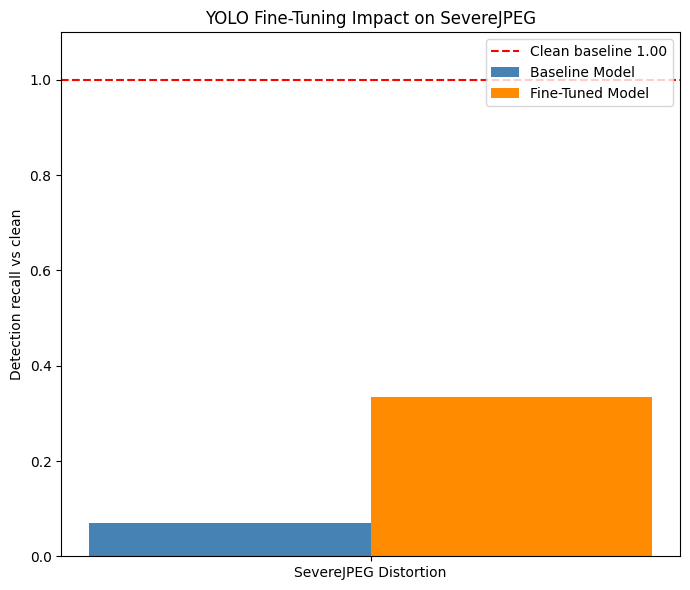

In [5]:
# 1. התקנה מחדש של ספריות במקרה של איפוס קולאב
!pip install -q ultralytics

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torchvision.ops as ops
from pathlib import Path
from PIL import Image
from torchvision.datasets import VOCSegmentation
from ultralytics import YOLO

# 2. הגדרות ונתיבים - חיפוש המשקלים המאומנים מהשלב הקודם
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA_DIR = PROJECT_ROOT / "data"
RESULTS_DIR = PROJECT_ROOT / "results"

# הנתיב שבו YOLO שמר את המשקלים הטובים ביותר בסיום האימון
FT_WEIGHTS = Path("/content/runs/detect/train/weights/best.pt")

if not FT_WEIGHTS.exists():
    print("Error: Fine-tuned weights not found. If Colab disconnected and wiped the disk, please rerun the training cell (cell 4) first.")
else:
    print(f"Found fine-tuned weights at: {FT_WEIGHTS}")

    # 3. טעינת המודלים (הרגיל והמאומן מחדש)
    yolo_base = YOLO("yolo11n.pt")
    yolo_ft = YOLO(str(FT_WEIGHTS))

    # 4. טעינת הנתונים (100 התמונות הקבועות שלנו)
    dataset = VOCSegmentation(root=DATA_DIR, year="2012", image_set="train", download=True)
    selected_indices_path = RESULTS_DIR / "selected_indices.csv"
    if selected_indices_path.exists():
        selected_indices = pd.read_csv(selected_indices_path)["dataset_index"].tolist()
    else:
        rng = np.random.default_rng(10)
        selected_indices = sorted(rng.choice(len(dataset), size=100, replace=False).tolist())

    # 5. פונקציית עיוות ה-JPEG (זה העיוות שעליו אימנו את המודל)
    def apply_jpeg_compression(img_pil, quality=5):
        img_np = np.array(img_pil.convert("RGB"))
        encode_param = [int(cv2.IMWRITE_JPEG_QUALITY), quality]
        _, encimg = cv2.imencode('.jpg', cv2.cvtColor(img_np, cv2.COLOR_RGB2BGR), encode_param)
        decimg = cv2.imdecode(encimg, 1)
        return cv2.cvtColor(decimg, cv2.COLOR_BGR2RGB)

    # 6. פונקציה לחישוב מדד ההתאמה (Recall vs Clean)
    def compute_recall(clean_res, test_res, iou_thresh=0.5):
        clean_boxes = clean_res.boxes.xyxy.cpu()
        clean_cls = clean_res.boxes.cls.cpu()
        test_boxes = test_res.boxes.xyxy.cpu()
        test_cls = test_res.boxes.cls.cpu()

        if len(clean_boxes) == 0:
            return 1.0 if len(test_boxes) == 0 else 0.0
        if len(test_boxes) == 0:
            return 0.0

        ious = ops.box_iou(clean_boxes, test_boxes)
        matched = 0
        used_test_indices = set()

        for i, c_cls in enumerate(clean_cls):
            best_iou = 0
            best_idx = -1
            for j, t_cls in enumerate(test_cls):
                if j in used_test_indices or c_cls != t_cls: continue
                if ious[i, j] > best_iou:
                    best_iou = ious[i, j].item()
                    best_idx = j
            if best_iou >= iou_thresh:
                matched += 1
                used_test_indices.add(best_idx)

        return matched / len(clean_boxes)

    print("Evaluating Baseline YOLO vs Fine-Tuned YOLO on SevereJPEG distortions...")
    base_dist_recalls = []
    ft_dist_recalls = []

    # 7. לולאת ההערכה על התמונות
    for idx in selected_indices:
        img_pil, _ = dataset[idx]
        img_np = np.array(img_pil.convert("RGB"))

        # יצירת התמונה המעוותת
        img_dist = apply_jpeg_compression(img_pil)

        # הרצת מודל הבסיס על התמונה הנקייה (כדי לקבל את "תמונת האמת")
        res_clean = yolo_base.predict(img_np, verbose=False)[0]

        # הרצת שני המודלים על התמונה המעוותת
        res_base_dist = yolo_base.predict(img_dist, verbose=False)[0]
        res_ft_dist = yolo_ft.predict(img_dist, verbose=False)[0]

        base_dist_recalls.append(compute_recall(res_clean, res_base_dist))
        ft_dist_recalls.append(compute_recall(res_clean, res_ft_dist))

    # 8. סיכום ויצירת גרף ההשוואה
    mean_base = np.mean(base_dist_recalls)
    mean_ft = np.mean(ft_dist_recalls)

    print(f"\n--- Results (SevereJPEG) ---")
    print(f"Baseline YOLO (no FT): {mean_base:.3f}")
    print(f"Fine-Tuned YOLO: {mean_ft:.3f}")

    labels = ['SevereJPEG Distortion']
    val_base = [mean_base]
    val_ft = [mean_ft]

    x = np.arange(len(labels))
    width = 0.35

    fig, ax = plt.subplots(figsize=(7, 6))
    ax.bar(x - width/2, val_base, width, label='Baseline Model', color='steelblue')
    ax.bar(x + width/2, val_ft, width, label='Fine-Tuned Model', color='darkorange')

    ax.axhline(y=1.0, color='r', linestyle='--', label='Clean baseline 1.00')

    ax.set_ylabel('Detection recall vs clean')
    ax.set_title('YOLO Fine-Tuning Impact on SevereJPEG')
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylim(0, 1.1)
    ax.legend(loc='upper right')

    plt.tight_layout()
    plt.show()


Starting SNR Sweep for Low Light on YOLO (this will take a couple of minutes)...
Brightness -0.1: Mean SNR = 14.1 dB, Recall = 0.890
Brightness -0.2: Mean SNR = 8.7 dB, Recall = 0.821
Brightness -0.3: Mean SNR = 5.6 dB, Recall = 0.695
Brightness -0.4: Mean SNR = 3.7 dB, Recall = 0.617
Brightness -0.5: Mean SNR = 2.3 dB, Recall = 0.524
Brightness -0.6: Mean SNR = 1.4 dB, Recall = 0.404
Brightness -0.7: Mean SNR = 0.8 dB, Recall = 0.240
Brightness -0.8: Mean SNR = 0.4 dB, Recall = 0.175
Brightness -0.9: Mean SNR = 0.1 dB, Recall = 0.038


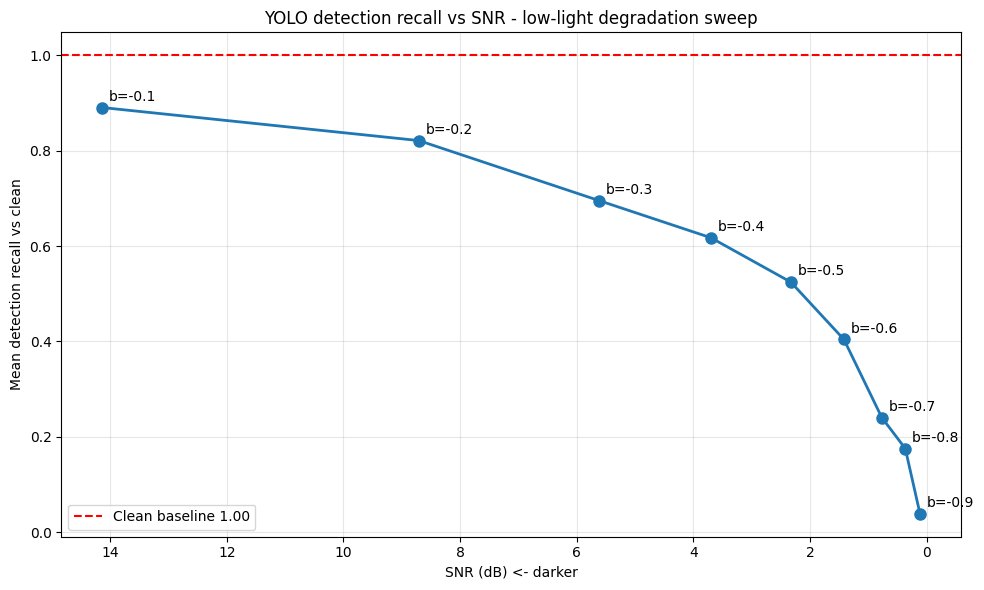

In [6]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torchvision.ops as ops
import albumentations as A
from ultralytics import YOLO
from torchvision.datasets import VOCSegmentation
from pathlib import Path

# -- 1. הגדרות וטעינת נתונים --
DATA_DIR = Path.cwd() / "data" if Path.cwd().name != "notebooks" else Path.cwd().parent / "data"
RESULTS_DIR = Path.cwd() / "results" if Path.cwd().name != "notebooks" else Path.cwd().parent / "results"

dataset = VOCSegmentation(root=DATA_DIR, year="2012", image_set="train", download=True)
if (RESULTS_DIR / "selected_indices.csv").exists():
    selected_indices = pd.read_csv(RESULTS_DIR / "selected_indices.csv")["dataset_index"].tolist()
else:
    selected_indices = sorted(np.random.default_rng(10).choice(len(dataset), size=100, replace=False).tolist())

yolo_model = YOLO("yolo11n.pt")

# -- 2. פונקציות SNR ומדדים מהמצגת --
def compute_snr(clean_rgb, dark_rgb):
    clean = clean_rgb.astype(np.float64)
    noise = clean - dark_rgb.astype(np.float64)
    signal_power = np.mean(clean ** 2)
    noise_power = np.mean(noise ** 2)
    return 10.0 * np.log10(signal_power / noise_power) if noise_power > 0 else np.inf

def compute_recall(clean_res, test_res, iou_thresh=0.5):
    clean_boxes = clean_res.boxes.xyxy.cpu()
    test_boxes = test_res.boxes.xyxy.cpu()
    if len(clean_boxes) == 0: return 1.0 if len(test_boxes) == 0 else 0.0
    if len(test_boxes) == 0: return 0.0
    ious = ops.box_iou(clean_boxes, test_boxes)
    matched = 0
    used = set()
    for i in range(len(clean_boxes)):
        best_iou = 0
        best_idx = -1
        for j in range(len(test_boxes)):
            if j in used or clean_res.boxes.cls[i] != test_res.boxes.cls[j]: continue
            if ious[i, j] > best_iou:
                best_iou = ious[i, j].item()
                best_idx = j
        if best_iou >= iou_thresh:
            matched += 1
            used.add(best_idx)
    return matched / len(clean_boxes)

# -- 3. הרצת ה-Sweep על 9 רמות תאורה --
print("Starting SNR Sweep for Low Light on YOLO (this will take a couple of minutes)...")
brightness_levels = [-0.1, -0.2, -0.3, -0.4, -0.5, -0.6, -0.7, -0.8, -0.9]
snr_vals = []
recall_vals = []

for b in brightness_levels:
    aug = A.RandomBrightnessContrast(brightness_limit=(b, b), contrast_limit=(0, 0), p=1.0)
    lvl_snr, lvl_rec = [], []

    for idx in selected_indices:
        img_pil, _ = dataset[idx]
        clean_rgb = np.array(img_pil.convert("RGB"))
        dark_rgb = aug(image=clean_rgb)["image"]

        lvl_snr.append(compute_snr(clean_rgb, dark_rgb))

        res_clean = yolo_model.predict(clean_rgb, verbose=False)[0]
        res_dark = yolo_model.predict(dark_rgb, verbose=False)[0]

        lvl_rec.append(compute_recall(res_clean, res_dark))

    snr_vals.append(np.mean(lvl_snr))
    recall_vals.append(np.mean(lvl_rec))
    print(f"Brightness {b}: Mean SNR = {snr_vals[-1]:.1f} dB, Recall = {recall_vals[-1]:.3f}")

# -- 4. ציור הגרף --
plt.figure(figsize=(10, 6))
plt.plot(snr_vals, recall_vals, marker='o', markersize=8, linestyle='-', linewidth=2)
for i, b in enumerate(brightness_levels):
    plt.annotate(f"b={b}", (snr_vals[i], recall_vals[i]), textcoords="offset points", xytext=(5,5), ha='left')

plt.axhline(y=1.0, color='r', linestyle='--', label='Clean baseline 1.00')
plt.gca().invert_xaxis() # SNR הולך מגבוה לנמוך ככל שחשוך יותר
plt.xlabel('SNR (dB) <- darker')
plt.ylabel('Mean detection recall vs clean')
plt.title('YOLO detection recall vs SNR - low-light degradation sweep')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
